In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import copy
import cv2

# --- Configuration ---
NUM_CLIENTS = 3
GLOBAL_ROUNDS = 3     
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
LEARNING_RATE = 0.01
SHARDS_PER_CLIENT = 2

# --- UI Settings ---
CANVAS_W, CANVAS_H = 1600, 950 
BG_COLOR = (20, 20, 20)      
GRID_COLOR = (50, 50, 50)    
TEXT_COLOR = (220, 220, 220) 

CLIENT_COLORS = [
    (0, 215, 255),   # Gold
    (50, 205, 50),   # Lime Green
    (0, 165, 255),   # Orange
    (255, 191, 0),   # Deep Sky Blue
    (90, 90, 255)    # Red
]

# --- Device Config ---
def get_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    elif torch.backends.mps.is_available(): return torch.device("mps")
    else: return torch.device("cpu")

DEVICE = get_device()
print(f"Using device: {DEVICE}")

torch.manual_seed(0)
np.random.seed(0)

# --- Visualization Engine ---
class Visualizer:
    def __init__(self):
        self.canvas = np.zeros((CANVAS_H, CANVAS_W, 3), dtype=np.uint8)
        self.canvas[:] = BG_COLOR
        self.global_acc = []
        self.global_loss = []
        self.client_losses = [[] for _ in range(NUM_CLIENTS)]
        self.layout = self._define_layout()
        self._draw_static_interface()

    def _define_layout(self):
        layout = {}
        top_margin = 60; side_margin = 40; mid_gap = 20
        top_h = 350
        top_w = (CANVAS_W - (2 * side_margin) - mid_gap) // 2
        layout['global_acc']  = (side_margin, top_margin, top_w, top_h)
        layout['global_loss'] = (side_margin + top_w + mid_gap, top_margin, top_w, top_h)
        bottom_y = top_margin + top_h + 50
        bottom_h = 350
        total_w_clients = CANVAS_W - (2 * side_margin)
        gap_clients = 15
        client_w = (total_w_clients - (gap_clients * (NUM_CLIENTS - 1))) // NUM_CLIENTS
        layout['clients'] = []
        for i in range(NUM_CLIENTS):
            x = side_margin + (i * (client_w + gap_clients))
            layout['clients'].append((x, bottom_y, client_w, bottom_h))
        return layout

    def _draw_static_interface(self):
        cv2.rectangle(self.canvas, (0, 0), (CANVAS_W, 50), (40, 40, 40), -1)
        self.draw_text("FEDERATED LEARNING LIVE DASHBOARD", (CANVAS_W//2 - 220, 35), scale=1.0, color=(255, 255, 255), thickness=2)
        self.draw_text(f"Device: {DEVICE}", (CANVAS_W - 200, 35), scale=0.6, color=(150, 150, 150))
        self._draw_box(self.layout['global_acc'], "Global Accuracy (%)")
        self._draw_box(self.layout['global_loss'], "Global Loss")
        for i, rect in enumerate(self.layout['clients']):
            self._draw_box(rect, f"Client {i} Training Loss", color=CLIENT_COLORS[i])

    def _draw_box(self, rect, title, color=TEXT_COLOR):
        x, y, w, h = rect
        cv2.rectangle(self.canvas, (x, y), (x+w, y+h), (30, 30, 30), -1)
        cv2.rectangle(self.canvas, (x, y), (x+w, y+h), (60, 60, 60), 1)
        self.draw_text(title, (x, y - 10), scale=0.5, color=color, thickness=1)

    def draw_text(self, text, pos, scale=0.5, color=TEXT_COLOR, thickness=1):
        cv2.putText(self.canvas, text, pos, cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)

    def draw_chart(self, data, rect, y_limit=None, line_color=(0, 255, 0), fill=False, auto_scale=True):
        if len(data) == 0: return
        x, y, w, h = rect
        cv2.rectangle(self.canvas, (x+1, y+1), (x+w-1, y+h-1), (30, 30, 30), -1)
        pad_l, pad_r, pad_t, pad_b = 45, 10, 20, 30 
        plot_x = x + pad_l; plot_y = y + pad_t
        plot_w = w - (pad_l + pad_r); plot_h = h - (pad_t + pad_b)
        
        if y_limit is not None:
            max_val = y_limit; min_val = 0
        else:
            max_val = max(data); min_val = min(data)
            if max_val == min_val: max_val += 0.1; min_val -= 0.1
            range_val = max_val - min_val
            max_val += range_val * 0.1; min_val = max(0, min_val - range_val * 0.1)

        num_grid_lines = 4
        for i in range(num_grid_lines + 1):
            gy = int(plot_y + plot_h - (i * (plot_h / num_grid_lines)))
            cv2.line(self.canvas, (plot_x, gy), (plot_x + plot_w, gy), GRID_COLOR, 1)
            val = min_val + (i / num_grid_lines) * (max_val - min_val)
            self.draw_text(f"{val:.2f}", (x + 2, gy + 5), scale=0.4, color=(150, 150, 150))

        cv2.line(self.canvas, (plot_x, plot_y), (plot_x, plot_y + plot_h), (100, 100, 100), 2)
        cv2.line(self.canvas, (plot_x, plot_y + plot_h), (plot_x + plot_w, plot_y + plot_h), (100, 100, 100), 2)

        points = []
        if len(data) == 1:
            norm_val = (data[0] - min_val) / (max_val - min_val)
            py = int((plot_y + plot_h) - (norm_val * plot_h))
            py = max(plot_y, min(plot_y + plot_h, py))
            cv2.circle(self.canvas, (plot_x, py), 4, line_color, -1)
            points.append((plot_x, py))
        else:
            for i, val in enumerate(data):
                px = int(plot_x + (i / (len(data) - 1)) * plot_w)
                norm_val = (val - min_val) / (max_val - min_val)
                py = int((plot_y + plot_h) - (norm_val * plot_h))
                py = max(plot_y, min(plot_y + plot_h, py))
                points.append((px, py))

        for i in range(len(points) - 1):
            cv2.line(self.canvas, points[i], points[i+1], line_color, 2)
        if fill and len(points) > 1:
            poly_points = np.array([[(points[0][0], plot_y+plot_h)] + points + [(points[-1][0], plot_y+plot_h)]], dtype=np.int32)
            overlay = self.canvas.copy()
            cv2.fillPoly(overlay, poly_points, line_color)
            cv2.addWeighted(overlay, 0.3, self.canvas, 0.7, 0, self.canvas)
        self.draw_text(f"{data[-1]:.2f}", (plot_x + plot_w - 50, plot_y + 15), scale=0.6, color=line_color, thickness=2)

    def update_client_live(self, client_id, loss_val):
        self.client_losses[client_id].append(loss_val)
        rect = self.layout['clients'][client_id]
        self.draw_chart(self.client_losses[client_id], rect, line_color=CLIENT_COLORS[client_id], fill=True, auto_scale=True)
        cv2.imshow("Federated Learning Dashboard", self.canvas)
        cv2.waitKey(1)

    def reset_client_plot(self, client_id):
        self.client_losses[client_id] = []
        rect = self.layout['clients'][client_id]
        self._draw_box(rect, f"Client {client_id} Training Loss", color=CLIENT_COLORS[client_id])

    def update_global(self, round_num, g_acc, g_loss):
        self.global_acc.append(g_acc)
        self.global_loss.append(g_loss)
        self.draw_chart(self.global_acc, self.layout['global_acc'], y_limit=100, line_color=(255, 255, 0))
        self.draw_chart(self.global_loss, self.layout['global_loss'], line_color=(255, 0, 255))
        cv2.rectangle(self.canvas, (0, CANVAS_H-50), (CANVAS_W, CANVAS_H), BG_COLOR, -1)
        status_text = f"COMPLETED ROUND {round_num}/{GLOBAL_ROUNDS} | Global Accuracy: {g_acc:.2f}% | Global Loss: {g_loss:.4f}"
        self.draw_text(status_text, (30, CANVAS_H - 15), scale=0.7, color=(0, 255, 0))
        cv2.imshow("Federated Learning Dashboard", self.canvas)
        cv2.waitKey(1)

# --- FL Logic ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CustomSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx): return self.dataset[self.indices[idx]]

def get_non_iid_loaders(num_clients, shards_per_client):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)
    labels = train_ds.targets.numpy()
    idxs = np.argsort(labels)
    num_shards = num_clients * shards_per_client
    num_imgs = len(train_ds) // num_shards
    idxs_shards = [idxs[i*num_imgs:(i+1)*num_imgs] for i in range(num_shards)]
    loaders = []
    shard_idx = 0
    for i in range(num_clients):
        indices = []
        for _ in range(shards_per_client):
            indices.extend(idxs_shards[shard_idx])
            shard_idx += 1
        loaders.append(DataLoader(CustomSubset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True))
    return loaders, DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    correct = 0; total = 0; loss = 0.0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            loss += criterion(output, target).item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total, loss / len(loader)

def local_train(model, loader, epochs, lr, viz, client_id):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    viz.reset_client_plot(client_id)
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            if batch_idx % 2 == 0:
                viz.update_client_live(client_id, loss.item())
                if cv2.waitKey(1) & 0xFF == ord('q'): return True
    return False

def fed_avg(client_weights):
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        for i in range(1, len(client_weights)):
            avg[key] += client_weights[i][key]
        avg[key] = torch.div(avg[key], len(client_weights))
    return avg

# --- Main Training Function ---
def train_federated_model():
    print("Initializing Data and Dashboard...")
    client_loaders, test_loader = get_non_iid_loaders(NUM_CLIENTS, SHARDS_PER_CLIENT)
    global_model = SimpleCNN().to(DEVICE)
    viz = Visualizer()
    
    print("Starting Training...")
    
    # List to store the final weights of all clients
    final_client_weights = []

    for round_idx in range(GLOBAL_ROUNDS):
        print(f"--- Round {round_idx + 1} Started ---")
        global_weights = global_model.state_dict()
        client_weights_list = []
        
        for i in range(NUM_CLIENTS):
            c_model = SimpleCNN().to(DEVICE)
            c_model.load_state_dict(copy.deepcopy(global_weights))
            
            stopped = local_train(c_model, client_loaders[i], LOCAL_EPOCHS, LEARNING_RATE, viz, i)
            if stopped: 
                print("Stopped by user."); cv2.destroyAllWindows(); return None, None, None
            
            client_weights_list.append(c_model.state_dict())
        
        # Store weights from the last round
        final_client_weights = client_weights_list

        agg_weights = fed_avg(client_weights_list)
        global_model.load_state_dict(agg_weights)
        
        g_acc, g_loss = evaluate(global_model, test_loader)
        
        print(f"Round {round_idx+1} | Acc: {g_acc:.2f}% | Loss: {g_loss:.4f}")
        viz.update_global(round_idx + 1, g_acc, g_loss)

    print("Training Complete. Press any key in window to close.")
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    # Convert weights back to models
    local_models = []
    for weights in final_client_weights:
        m = SimpleCNN().to(DEVICE)
        m.load_state_dict(weights)
        local_models.append(m)

    # RETURN global model, ALL local models, and loader
    return global_model, local_models, test_loader

# --- Execute Training ---
trained_model, local_models_list, test_loader_ref = train_federated_model()

ModuleNotFoundError: No module named 'torch'

Comparing Global vs. Local Client Models...


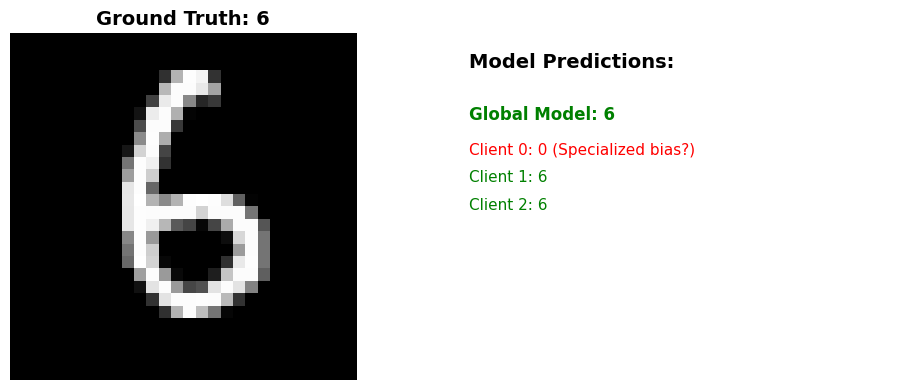

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def compare_predictions(global_model, local_models, loader):
    if global_model is None or local_models is None:
        print("Error: Models not found.")
        return

    # 1. Get a batch & random image
    data_iter = iter(loader)
    images, labels = next(data_iter)
    idx = np.random.randint(0, len(images))
    
    img_tensor = images[idx]
    true_label = labels[idx].item()
    
    # 2. Setup Device & Input
    device = next(global_model.parameters()).device
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 3. Collect Predictions
    predictions = {}
    
    # Global Prediction
    global_model.eval()
    with torch.no_grad():
        out = global_model(input_tensor)
        predictions['Global Model'] = torch.argmax(out, dim=1).item()
        
    # Local Predictions
    for i, model in enumerate(local_models):
        model.eval()
        with torch.no_grad():
            out = model(input_tensor)
            predictions[f'Client {i}'] = torch.argmax(out, dim=1).item()
            
    # 4. Visualize Results
    img_numpy = img_tensor.squeeze().numpy()
    
    plt.figure(figsize=(10, 4))
    
    # Plot Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_numpy, cmap='gray')
    plt.title(f"Ground Truth: {true_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    
    # Plot Text Results
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    y_pos = 0.9
    plt.text(0.1, y_pos, "Model Predictions:", fontsize=14, fontweight='bold')
    y_pos -= 0.15
    
    # Print Global Result
    pred = predictions['Global Model']
    color = "green" if pred == true_label else "red"
    plt.text(0.1, y_pos, f"Global Model: {pred}", fontsize=12, color=color, fontweight='bold')
    y_pos -= 0.1
    
    # Print Local Results
    for i in range(len(local_models)):
        key = f"Client {i}"
        pred = predictions[key]
        color = "green" if pred == true_label else "red" # (or orange for bias check)
        
        # Add a note if it looks like bias (e.g. model guessed wrong)
        note = " (Specialized bias?)" if pred != true_label else ""
        
        plt.text(0.1, y_pos, f"{key}: {pred}{note}", fontsize=11, color=color)
        y_pos -= 0.08
        
    plt.tight_layout()
    plt.show()

# Run Comparison
print("Comparing Global vs. Local Client Models...")
compare_predictions(trained_model, local_models_list, test_loader_ref)

Comparing Global vs Local Client Models for all digits 0 to 9...
Comparing Global vs Local Client Models for digit 0...


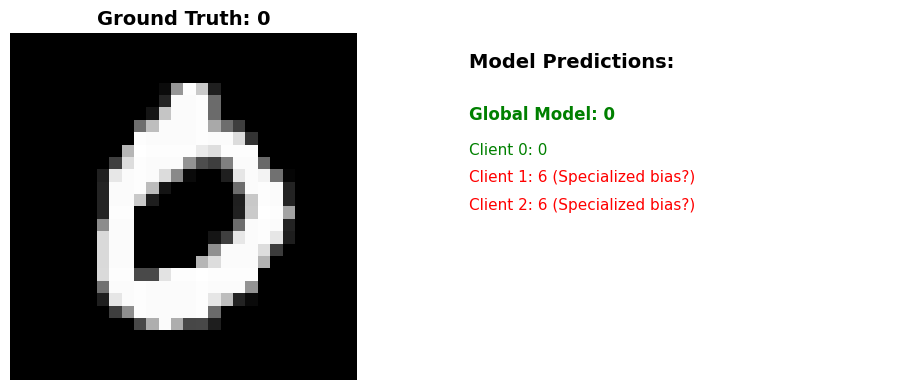

Comparing Global vs Local Client Models for digit 1...


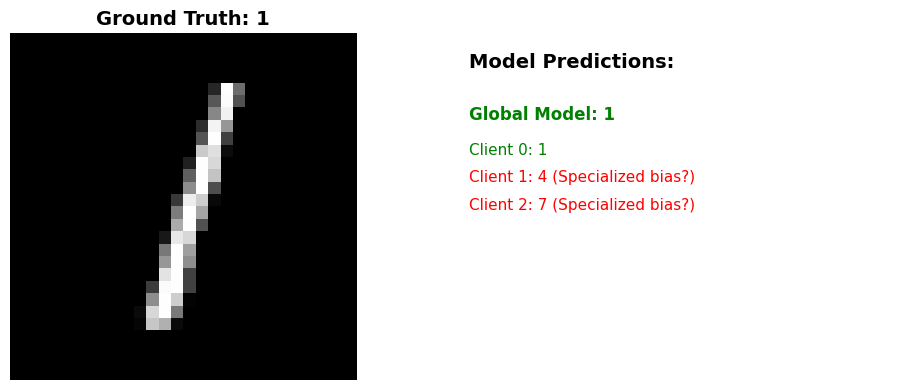

Comparing Global vs Local Client Models for digit 2...


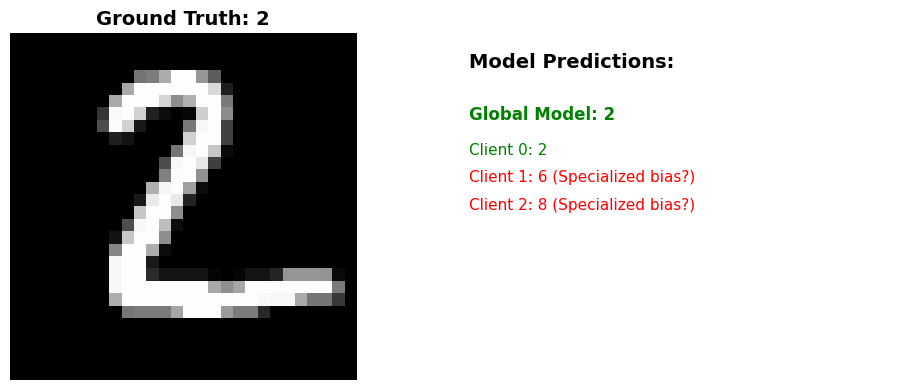

Comparing Global vs Local Client Models for digit 3...


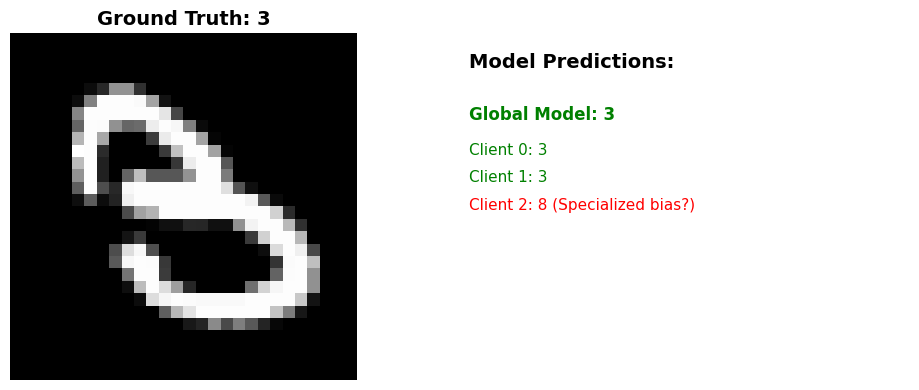

Comparing Global vs Local Client Models for digit 4...


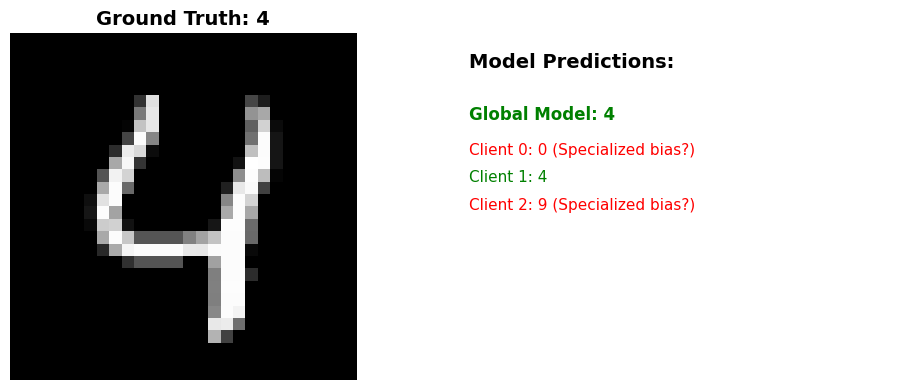

Comparing Global vs Local Client Models for digit 5...


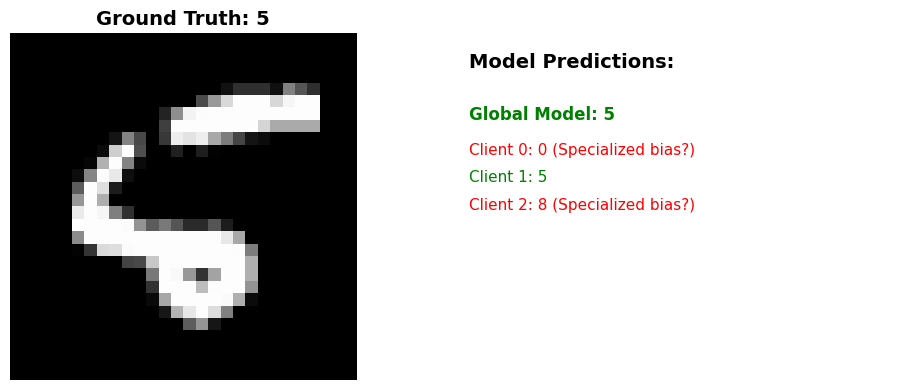

Comparing Global vs Local Client Models for digit 6...


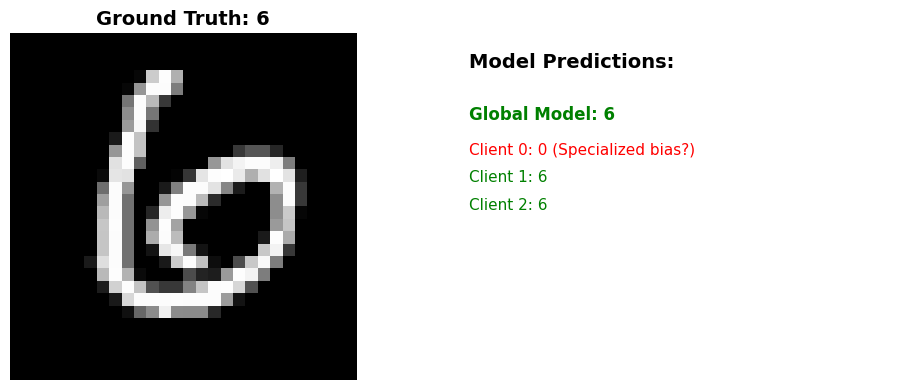

Comparing Global vs Local Client Models for digit 7...


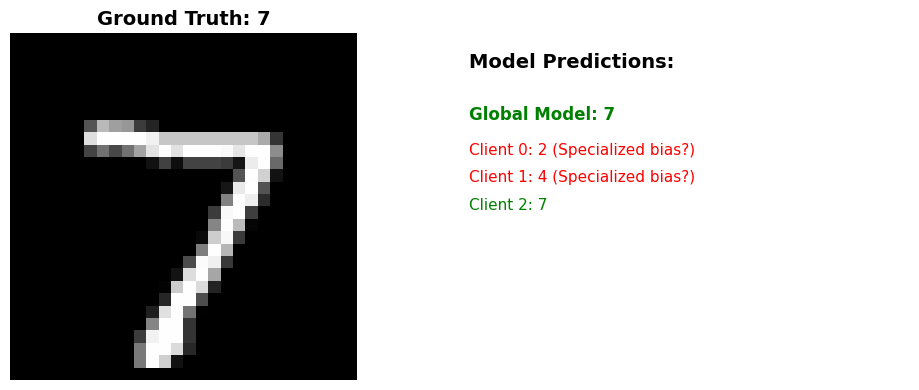

Comparing Global vs Local Client Models for digit 8...


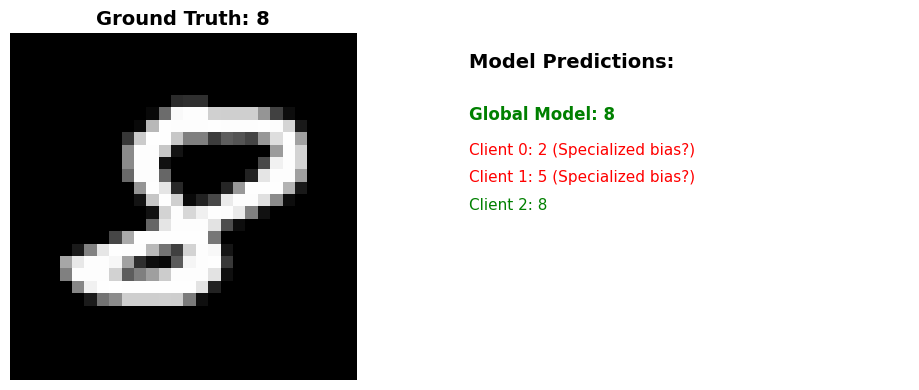

Comparing Global vs Local Client Models for digit 9...


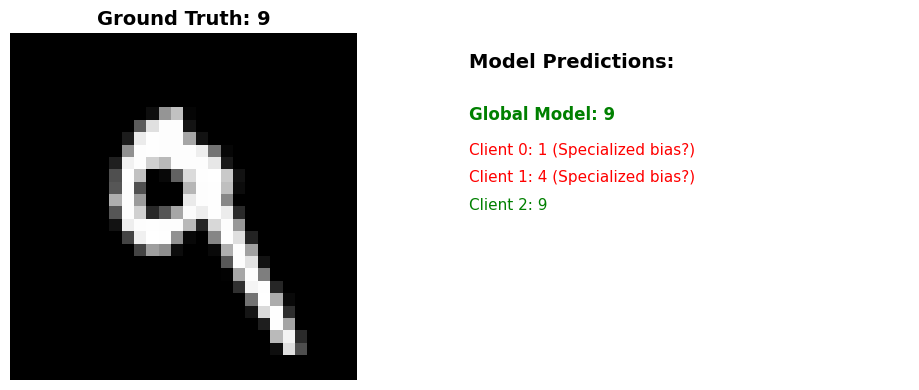

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def compare_predictions_single(global_model, local_models, img_tensor, true_label):
    # Device and input
    device = next(global_model.parameters()).device
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Collect predictions
    predictions = {}

    global_model.eval()
    with torch.no_grad():
        out = global_model(input_tensor)
        predictions["Global Model"] = torch.argmax(out, dim=1).item()

    for i, model in enumerate(local_models):
        model.eval()
        with torch.no_grad():
            out = model(input_tensor)
            predictions[f"Client {i}"] = torch.argmax(out, dim=1).item()

    # Visualize
    img_numpy = img_tensor.squeeze().numpy()

    plt.figure(figsize=(10, 4))

    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_numpy, cmap="gray")
    plt.title(f"Ground Truth: {true_label}", fontsize=14, fontweight="bold")
    plt.axis("off")

    # Text
    plt.subplot(1, 2, 2)
    plt.axis("off")

    y_pos = 0.9
    plt.text(0.1, y_pos, "Model Predictions:", fontsize=14, fontweight="bold")
    y_pos -= 0.15

    # Global result
    pred = predictions["Global Model"]
    color = "green" if pred == true_label else "red"
    plt.text(0.1, y_pos, f"Global Model: {pred}", fontsize=12,
             color=color, fontweight="bold")
    y_pos -= 0.1

    # Local results
    for i in range(len(local_models)):
        key = f"Client {i}"
        pred = predictions[key]
        color = "green" if pred == true_label else "red"
        note = " (Specialized bias?)" if pred != true_label else ""
        plt.text(0.1, y_pos, f"{key}: {pred}{note}", fontsize=11, color=color)
        y_pos -= 0.08

    plt.tight_layout()
    plt.show()


def compare_predictions_all_classes(global_model, local_models, loader, num_classes=10):
    if global_model is None or local_models is None:
        print("Error: Models not found.")
        return

    # Collect one example per class from the loader
    class_examples = {c: None for c in range(num_classes)}

    for images, labels in loader:
        for i in range(len(labels)):
            label = labels[i].item()
            if class_examples[label] is None:
                class_examples[label] = images[i]
        if all(v is not None for v in class_examples.values()):
            break

    # Plot for each class using the same style
    for digit in range(num_classes):
        img_tensor = class_examples[digit]
        if img_tensor is None:
            print(f"No example found for class {digit}")
            continue

        print(f"Comparing Global vs Local Client Models for digit {digit}...")
        compare_predictions_single(global_model, local_models, img_tensor, digit)


# Usage
print("Comparing Global vs Local Client Models for all digits 0 to 9...")
compare_predictions_all_classes(trained_model, local_models_list, test_loader_ref)


Comparing Global vs Local Client Models for digits 0 to 9 in a 3 x 4 grid


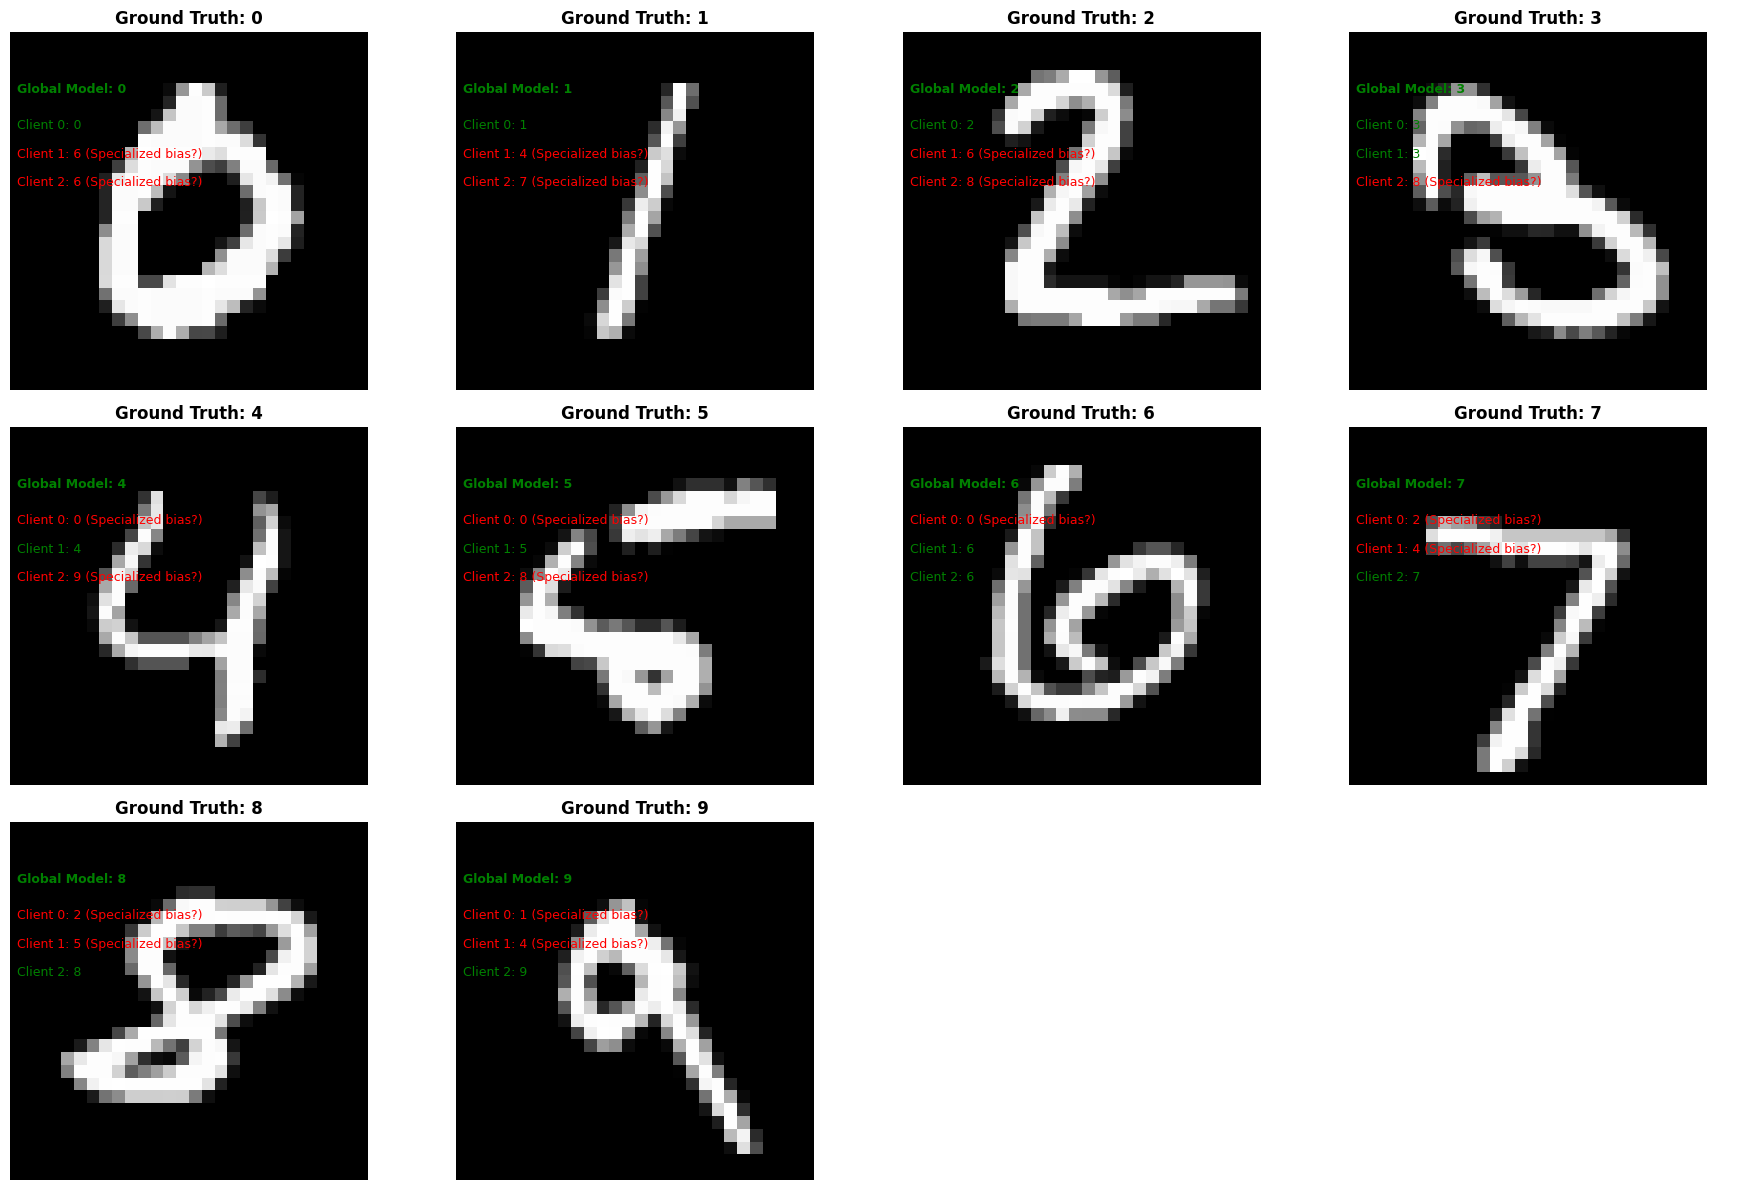

In [42]:
import matplotlib.pyplot as plt
import torch

def compare_predictions_3x4(global_model, local_models, loader, num_classes=10):
    if global_model is None or local_models is None:
        print("Error: Models not found.")
        return

    device = next(global_model.parameters()).device

    # Collect one example per class
    class_examples = {c: None for c in range(num_classes)}

    for images, labels in loader:
        for i in range(len(labels)):
            label = labels[i].item()
            if class_examples[label] is None:
                class_examples[label] = images[i]
        if all(v is not None for v in class_examples.values()):
            break

    # Create 3 x 4 grid
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()

    for idx in range(12):
        ax = axes[idx]
        ax.axis("off")

        if idx >= num_classes:
            continue

        digit = idx
        img_tensor = class_examples[digit]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # Predictions
        predictions = {}

        global_model.eval()
        with torch.no_grad():
            out = global_model(input_tensor)
            predictions["Global Model"] = torch.argmax(out, dim=1).item()

        for i, model in enumerate(local_models):
            model.eval()
            with torch.no_grad():
                out = model(input_tensor)
                predictions[f"Client {i}"] = torch.argmax(out, dim=1).item()

        # Show image
        ax.imshow(img_tensor.squeeze().numpy(), cmap="gray")

        # Title
        ax.set_title(
            f"Ground Truth: {digit}",
            fontsize=12,
            fontweight="bold"
        )

        # Text block
        y_pos = 0.95
        ax.text(0.02, y_pos, "Model Predictions:",
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold")
        y_pos -= 0.12

        # Global model
        pred = predictions["Global Model"]
        color = "green" if pred == digit else "red"
        ax.text(
            0.02, y_pos,
            f"Global Model: {pred}",
            transform=ax.transAxes,
            fontsize=9,
            color=color,
            fontweight="bold"
        )
        y_pos -= 0.1

        # Local clients 
        for i in range(len(local_models)):
            pred = predictions[f"Client {i}"]
            color = "green" if pred == digit else "red"
            note = " (Specialized bias?)" if pred != digit else ""
            ax.text(
                0.02, y_pos,
                f"Client {i}: {pred}{note}",
                transform=ax.transAxes,
                fontsize=9,
                color=color
            )
            y_pos -= 0.08

    plt.tight_layout()
    plt.show()


# Usage
print("Comparing Global vs Local Client Models for digits 0 to 9 in a 3 x 4 grid")
compare_predictions_3x4(
    trained_model,
    local_models_list,
    test_loader_ref
)
